<a href="https://colab.research.google.com/github/lakkshanarams-maker/aiml-colab/blob/main/decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
from google.colab import files
uploaded = files.upload()

Saving carprices.csv to carprices.csv


In [3]:
df = pd.read_csv('carprices.csv')


In [4]:
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
   Mileage  Age(yrs)  Sell Price($)
0    69000         6          18000
1    35000         3          34000
2    57000         5          26100
3    22500         2          40000
4    46000         4          31500

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Mileage        20 non-null     int64
 1   Age(yrs)       20 non-null     int64
 2   Sell Price($)  20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes
None

Missing values:
Mileage          0
Age(yrs)         0
Sell Price($)    0
dtype: int64


In [5]:
median_price = df['Sell Price($)'].median()
df['Price_Class'] = (df['Sell Price($)'] >= median_price).astype(int)

print("\nMedian Price:", median_price)
print("\nDataset with Price_Class:")
print(df.head())


Median Price: 26050.0

Dataset with Price_Class:
   Mileage  Age(yrs)  Sell Price($)  Price_Class
0    69000         6          18000            0
1    35000         3          34000            1
2    57000         5          26100            1
3    22500         2          40000            1
4    46000         4          31500            1


In [6]:
X = df[['Mileage', 'Age(yrs)']]
y = df['Price_Class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
model = DecisionTreeClassifier(random_state=42)


In [9]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)


Accuracy: 0.75


In [12]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[1 1]
 [0 2]]


In [13]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [14]:
new_data = pd.DataFrame({
    'Mileage': [45000],
    'Age(yrs)': [4]
})

predicted_class = model.predict(new_data)
predicted_prob = model.predict_proba(new_data)

print("\nPrediction for new data (Mileage=45000, Age=4):")
print("Predicted Class:", predicted_class[0])
print("Prediction Probabilities [Class 0, Class 1]:", predicted_prob[0])



Prediction for new data (Mileage=45000, Age=4):
Predicted Class: 1
Prediction Probabilities [Class 0, Class 1]: [0. 1.]


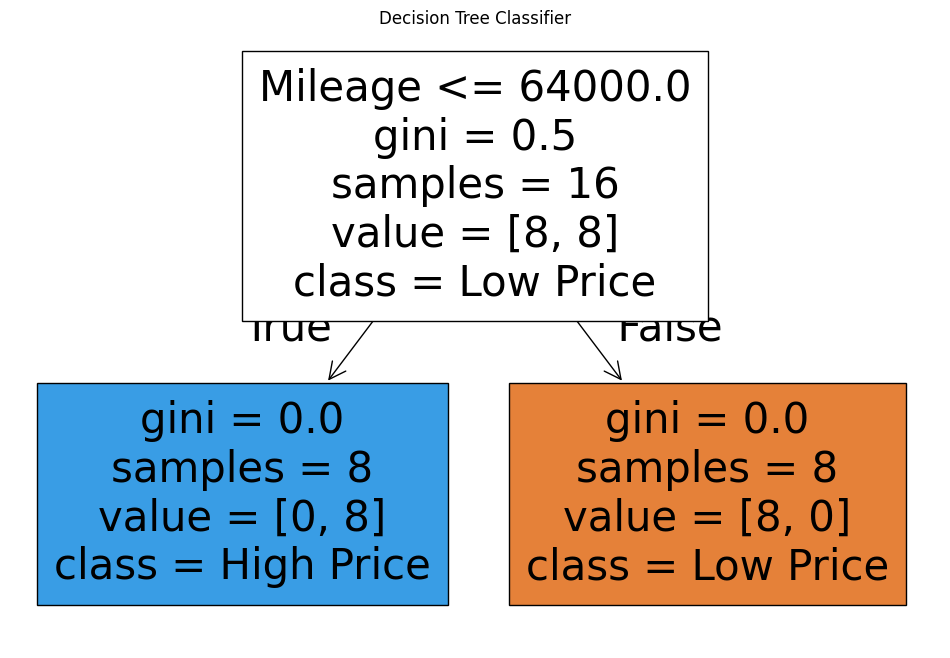

In [15]:
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=['Mileage', 'Age(yrs)'],
    class_names=['Low Price', 'High Price'],
    filled=True
)
plt.title("Decision Tree Classifier")
plt.show()